# Friedland 2026 NW weak-magnetism comparison

Checking whether the Friedland et al. 2026 luminosity-rescaling trick ($L_{\bar\nu_e} = L_{\nu_e}/1.22$) gives the same final $Y(A)$ as SkyNet's explicit [Horowitz (2002)](https://doi.org/10.1103/PhysRevD.65.043001) weak-magnetism/recoil correction for charged-current rates. Both runs use the no-GR (NW) setup from [Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067), following the earlier νp-process work in [Friedland, Mukhopadhyay, and Patwardhan (2025)](https://doi.org/10.1088/1475-7516/2025/02/005).

Single trajectory from `vp_wind_param.dat`, tuned to match Fig. 7 of Friedland 2026. Plot is final $Y(A)$ for one trajectory, not the averaged $\langle Y_A\rangle$ from Fig. 10 — that needs multiple trajectories (see last cell).

In [1]:
import os
import concurrent.futures
import subprocess
import textwrap

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (9.0, 5.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

trajectory = "trajectories/vp_wind_param.dat"
vp_process = os.environ.get("SKYNET_VP_PROCESS", "../../build/examples/vp-process-friedland/vp_process")
run_label = os.environ.get("SKYNET_RUN_LABEL", "wm_comparison")
output_dir = os.path.join("runs", run_label)
os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(trajectory):
    raise FileNotFoundError(trajectory)
if not os.path.exists(vp_process):
    raise FileNotFoundError(
        f"Missing {vp_process}. Build the example first, e.g. `cmake --preset pardiso && cmake --build build`."
    )

trajectory, vp_process, output_dir


('trajectories/vp_wind_param.dat',
 '../../build/examples/vp-process-friedland/vp_process',
 'runs/wm_comparison')

## Run the two no-GR cases

Parameters from [Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067) Table 1: $L_{\nu_e}(1\,\text{s}) = 7\times10^{51}$ erg/s, $T_{\nu_e} = 2.67$ MeV, $T_{\bar\nu_e} = 3.39$ MeV, $\eta_{\nu_e} = 2.1$, $\eta_{\bar\nu_e} = 1.5$. Luminosity decays exponentially with $t_0 = 1$ s and $t_d = 3$ s (Eq. 5.5 text). Density tail $\rho \propto t^{-2}$ from Appendix G.

Using `--max-dt 0.01` to keep runtime manageable; SkyNet still tightens the step when needed.

Run 1 (lbar-ratio): antineutrino luminosity scaled by $1/1.22$ to approximate weak-magnetism, equal temperatures.
Run 2 (wm): equal luminosities, explicit [Horowitz (2002)](https://doi.org/10.1103/PhysRevD.65.043001) weak-magnetism/recoil correction enabled.

In [2]:
t_end = os.environ.get("SKYNET_T_END", "30.0")
max_dt = os.environ.get("SKYNET_MAX_DT", "0.01")

COMMON_ARGS = [
    "--no-gr",
    "--L0", "7e51",
    "--T-nue", "2.67",
    "--T-nuebar", "3.39",
    "--eta-nue", "2.1",
    "--eta-nuebar", "1.5",
    "--tau-d", "3.0",
    "--t-ref", "1.0",
    "--t-end", t_end,
    "--max-dt", max_dt,
    "--rho-slope", "-2.0",
]

cases = {
    "friedland_lbar_tweak": {
        "label": "Friedland luminosity tweak",
        "color": "black",
        "prefix": os.path.join(output_dir, "friedland_lbar_tweak"),
        "wm_state": "off",
        "lbar_ratio_label": "0.819672",
        "args": ["--no-wm-recoil", "--lbar-ratio", f"{1.0 / 1.22:.12f}"],
    },
    "weak_magnetism": {
        "label": "Explicit weak magnetism",
        "color": "#c62828",
        "prefix": os.path.join(output_dir, "weak_magnetism"),
        "wm_state": "on",
        "lbar_ratio_label": "1.000000",
        "args": ["--lbar-ratio", "1.0"],
    },
}

def completed_output(case):
    prefix = case["prefix"]
    h5_path = f"{prefix}.h5"
    stdout_path = f"{prefix}.stdout"
    if not os.path.exists(h5_path) or not os.path.exists(stdout_path):
        return False
    with open(stdout_path, errors="replace") as f:
        stdout_text = f.read()
    expected = [
        "Finished evolution",
        "GR blueshift: off",
        f"WM/recoil: {case['wm_state']}",
        f"lbar-ratio = {case['lbar_ratio_label']}",
    ]
    return all(marker in stdout_text for marker in expected)

def run_case(case):
    prefix = case["prefix"]
    h5_path = f"{prefix}.h5"
    stdout_path = f"{prefix}.stdout"
    if completed_output(case):
        print(f"Skipping completed output: {h5_path}")
        return
    if os.path.exists(h5_path) or os.path.exists(stdout_path):
        raise RuntimeError(
            f"Found incomplete or stale output for {case['label']}. "
            f"Move {prefix}.h5/.log/.stdout aside before rerunning."
        )

    cmd = [str(vp_process), str(trajectory), str(prefix), *COMMON_ARGS, *case["args"]]
    print("Running:")
    print(textwrap.fill(" ".join(cmd), width=100, subsequent_indent="  "))
    with open(stdout_path, "w") as stdout_file:
        result = subprocess.run(cmd, text=True, stdout=stdout_file, stderr=subprocess.STDOUT)
    with open(stdout_path, errors="replace") as stdout_file:
        tail = stdout_file.read()[-4000:]
    print(tail)
    if result.returncode != 0:
        raise subprocess.CalledProcessError(result.returncode, cmd)

with concurrent.futures.ThreadPoolExecutor(max_workers=len(cases)) as executor:
    futures = {executor.submit(run_case, case): name for name, case in cases.items()}
    for future in concurrent.futures.as_completed(futures):
        future.result()


Skipping completed output: runs/wm_comparison/friedland_lbar_tweak.h5
Skipping completed output: runs/wm_comparison/weak_magnetism.h5


In [3]:
def read_output(prefix):
    path = f"{prefix}.h5"
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    with h5py.File(path, "r") as f:
        data = {name: np.asarray(f[name]) for name in ["Time", "Temperature", "Density", "Ye", "Y", "A", "Z"]}
    data["path"] = path
    return data

def y_by_a(y, a):
    max_a = int(np.max(a))
    out = np.zeros(max_a + 1)
    np.add.at(out, a.astype(int), y)
    return np.arange(max_a + 1), out

outputs = {name: read_output(case["prefix"]) for name, case in cases.items()}

reference = outputs["friedland_lbar_tweak"]
for name, out in outputs.items():
    assert np.array_equal(reference["A"], out["A"]), f"A grid mismatch for {name}"
    assert np.array_equal(reference["Z"], out["Z"]), f"Z grid mismatch for {name}"

for name, case in cases.items():
    stdout_path = f"{case['prefix']}.stdout"
    with open(stdout_path, errors="replace") as f:
        stdout_text = f.read()
    assert "GR blueshift: off" in stdout_text, f"GR was not disabled for {name}"
    print(f"{case['label']}: {outputs[name]['path']}")

Friedland luminosity tweak: runs/wm_comparison/friedland_lbar_tweak.h5
Explicit weak magnetism: runs/wm_comparison/weak_magnetism.h5


## Final abundance pattern

Final $Y(A)$, styled after [Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067) Fig. 10. Labels mark p-nuclide mass numbers along the top. These are single-trajectory values, not the mass-outflow-rate weighted $\langle Y_A\rangle$.

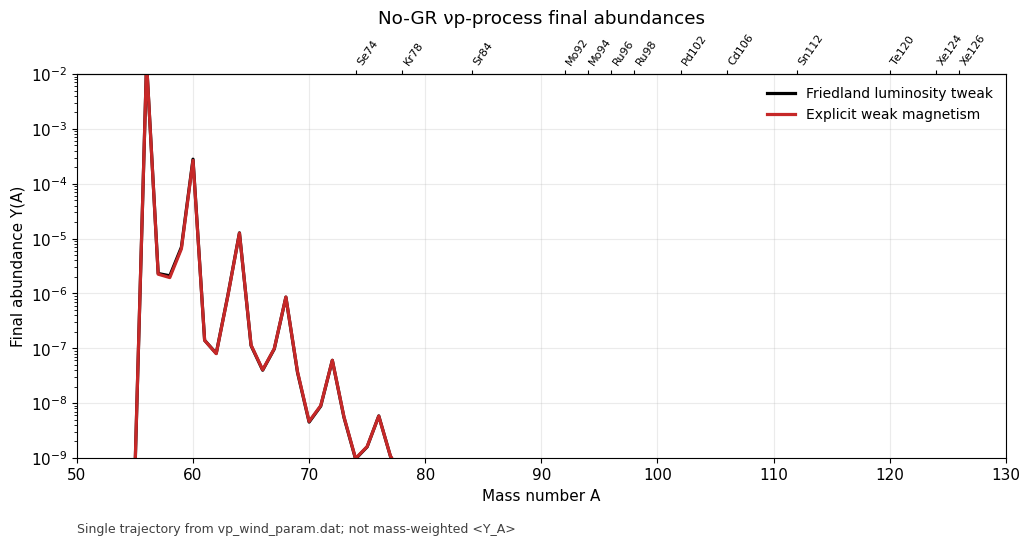

In [4]:
isotope_marks = [
    (74, "Se74"),
    (78, "Kr78"),
    (84, "Sr84"),
    (92, "Mo92"),
    (94, "Mo94"),
    (96, "Ru96"),
    (98, "Ru98"),
    (102, "Pd102"),
    (106, "Cd106"),
    (112, "Sn112"),
    (120, "Te120"),
    (124, "Xe124"),
    (126, "Xe126"),
]

fig, ax = plt.subplots(figsize=(10.8, 6.0))
abundance_floor = 1e-12

for name, case in cases.items():
    out = outputs[name]
    a_grid, y_a = y_by_a(out["Y"][-1], out["A"])
    mask = (a_grid >= 50) & (a_grid <= 130) & (y_a > abundance_floor)
    ax.plot(a_grid[mask], y_a[mask], lw=2.3, color=case["color"], label=case["label"])

ax.set_yscale("log")
ax.set_xscale("linear")
ax.set_xlim(50, 130)
ax.set_ylim(1e-9, 1e-2)
ax.set_xlabel("Mass number A")
ax.set_ylabel("Final abundance Y(A)")
ax.set_title("No-GR νp-process final abundances")
ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=10,
)
fig.text(
    0.10, 0.035,
    "Single trajectory from vp_wind_param.dat; not mass-weighted <Y_A>",
    ha="left",
    fontsize=9,
    color="0.25",
)

top = ax.secondary_xaxis("top")
top.set_xlim(ax.get_xlim())
top.set_xticks([a for a, _ in isotope_marks])
top.set_xticklabels([label for _, label in isotope_marks], rotation=55, ha="left", fontsize=8)
top.tick_params(axis="x", which="major", pad=2, length=3)

fig.subplots_adjust(left=0.10, right=0.96, bottom=0.16, top=0.80)
plt.show()

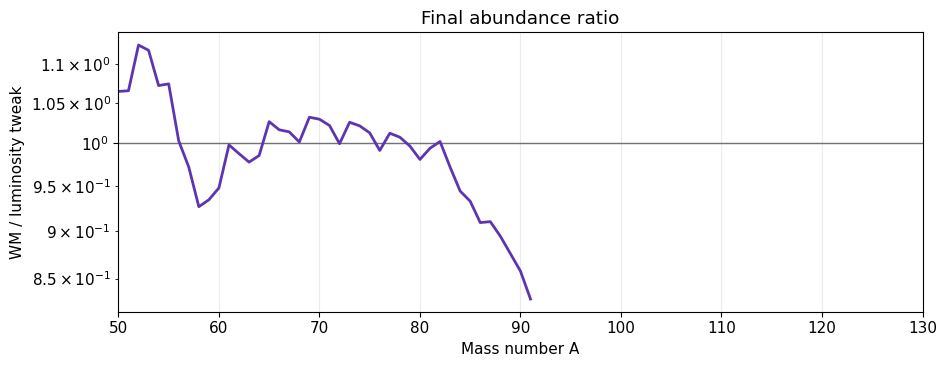

In [5]:
base_a, base_y = y_by_a(outputs["friedland_lbar_tweak"]["Y"][-1], outputs["friedland_lbar_tweak"]["A"])
wm_a, wm_y = y_by_a(outputs["weak_magnetism"]["Y"][-1], outputs["weak_magnetism"]["A"])
assert np.array_equal(base_a, wm_a)

ratio = np.full_like(base_y, np.nan, dtype=float)
valid = (base_y > 1e-14) & (wm_y > 1e-14)
ratio[valid] = wm_y[valid] / base_y[valid]

fig, ax = plt.subplots(figsize=(9.6, 3.8))
mask = (base_a >= 50) & (base_a <= 130) & np.isfinite(ratio)
ax.axhline(1.0, color="0.45", lw=1.0)
ax.plot(base_a[mask], ratio[mask], color="#5e35b1", lw=2.0)
ax.set_yscale("log")
ax.set_xlim(50, 130)
ax.set_xlabel("Mass number A")
ax.set_ylabel("WM / luminosity tweak")
ax.set_title("Final abundance ratio")
fig.tight_layout()
plt.show()

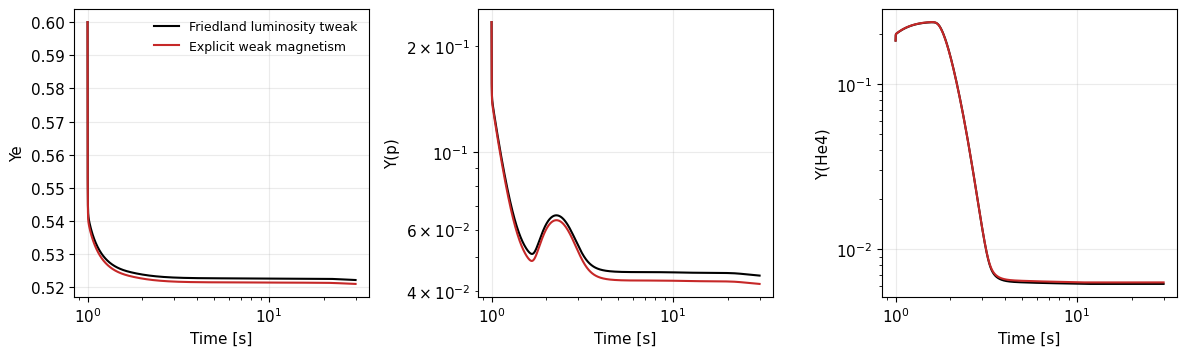

In [6]:
def isotope_index(a, z, out):
    matches = np.where((out["A"] == a) & (out["Z"] == z))[0]
    if len(matches) != 1:
        raise ValueError(f"Expected one isotope with A={a}, Z={z}, found {len(matches)}")
    return int(matches[0])

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.7), sharex=True)
for name, case in cases.items():
    out = outputs[name]
    n_idx = isotope_index(1, 0, out)
    p_idx = isotope_index(1, 1, out)
    alpha_idx = isotope_index(4, 2, out)
    times = out["Time"]
    axes[0].plot(times, out["Ye"], color=case["color"], label=case["label"])
    axes[1].plot(times, out["Y"][:, p_idx], color=case["color"])
    axes[2].plot(times, out["Y"][:, alpha_idx], color=case["color"])

axes[0].set_ylabel("Ye")
axes[1].set_ylabel("Y(p)")
axes[2].set_ylabel("Y(He4)")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Time [s]")
axes[1].set_yscale("log")
axes[2].set_yscale("log")
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

In [7]:
ranges = {
    "A >= 56": lambda a: a >= 56,
    "64 <= A <= 100": lambda a: (a >= 64) & (a <= 100),
    "90 <= A <= 106": lambda a: (a >= 90) & (a <= 106),
    "A > 100": lambda a: a > 100,
}

rows = []
for label, selector in ranges.items():
    row = {"range": label}
    for name, case in cases.items():
        a_grid, y_a = y_by_a(outputs[name]["Y"][-1], outputs[name]["A"])
        sel = selector(a_grid)
        row[case["label"]] = float(np.sum(a_grid[sel] * y_a[sel]))
    rows.append(row)

pd.DataFrame(rows)


,range,Friedland luminosity tweak,Explicit weak magnetism
0,A >= 56,9.310131e-01,9.328573e-01
1,64 <= A <= 100,8.981220e-04,8.868834e-04
2,90 <= A <= 106,1.944124e-11,1.646625e-11
3,A > 100,1.981144e-13,5.081635e-14


## Not $\langle Y_A\rangle$ yet

[Friedland et al. (2026)](https://doi.org/10.1088/1475-7516/2026/02/067) Fig. 10 shows the launch-time averaged abundance

$$
\langle Y_{A,Z}\rangle = \frac{\int Y_{A,Z}(t_{\mathrm{launch}})\dot M(t_{\mathrm{launch}})\,dt_{\mathrm{launch}}}{\int \dot M(t_{\mathrm{launch}})\,dt_{\mathrm{launch}}}
$$

which needs trajectories across $t_{\text{launch}} \approx 1$–7 s plus the outflow rate $\dot{M}$. I only have one trajectory in `vp_wind_param.dat` for now, so I'm plotting final $Y(A)$ for that single run. TODO: add more trajectories and compute $\langle Y_A\rangle$ properly.

## References

1. A. Friedland, D. J. Li, G. Lucente, I. Padilla-Gay, and A. V. Patwardhan, “νp-process in core-collapse supernovae: imprints of general relativistic effects,” Journal of Cosmology and Astroparticle Physics 2026, 067 (2026). [doi:10.1088/1475-7516/2026/02/067](https://doi.org/10.1088/1475-7516/2026/02/067); [arXiv:2508.02055](https://arxiv.org/abs/2508.02055)
2. C. J. Horowitz, “Weak magnetism for antineutrinos in supernovae,” Physical Review D 65, 043001 (2002). [doi:10.1103/PhysRevD.65.043001](https://doi.org/10.1103/PhysRevD.65.043001)
3. A. Friedland, P. Mukhopadhyay, and A. V. Patwardhan, “Successful νp-process in neutrino-driven outflows in core-collapse supernovae,” Journal of Cosmology and Astroparticle Physics 2025, 005 (2025). [doi:10.1088/1475-7516/2025/02/005](https://doi.org/10.1088/1475-7516/2025/02/005)